# Exploratory Data Analysis

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import uuid
import ast
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)

DATA_DIR = Path('data/') 
RUN_ID = datetime.now(timezone.utc).strftime('%Y%m%d_%H%M%S') + '_' + uuid.uuid4().hex[:6]
OUTPUT_DIR = Path('outputs') / f'eda_{RUN_ID}'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('DATA_DIR =', DATA_DIR.resolve())
print('OUTPUT_DIR =', OUTPUT_DIR.resolve())

DATA_DIR = /home/joris/Master/Semester 2/Recommender Systems/Final_Assignment_RS/data
OUTPUT_DIR = /home/joris/Master/Semester 2/Recommender Systems/Final_Assignment_RS/outputs/eda_20260613_081219_e0be71


In [4]:
train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')
sample = pd.read_csv(DATA_DIR / 'sample_submission.csv')
meta = pd.read_csv(DATA_DIR / 'item_meta.csv')

for name, df in [('train', train), ('test', test), ('sample_submission', sample), ('item_meta', meta)]:
    print(f'\n{name}: shape={df.shape}')
    display(df.head())


train: shape=(162727, 3)


,item_id,user_id,timestamp
0,7926,22119,1020909887000
1,6719,3664,1072719074000
2,6719,5466,1090094915000
3,6719,16280,1152498722000
4,9677,6383,1161911421000



test: shape=(15460, 3)


,item_id,user_id,timestamp
0,4942,3927,1618965129014
1,959,8359,1618965468770
2,9704,1778,1618966728616
3,8483,20375,1618967691412
4,8750,17076,1618969471839



sample_submission: shape=(2255, 3)


,ID,user_id,item_id
0,12,12,"6312,12419,6891,664,4243,8377,7962,6635,12842,..."
1,14,14,"7809,5867,9559,3579,8269,2282,4618,2290,12384,..."
2,17,17,"10132,13098,4105,8726,11554,13275,9862,2408,50..."
3,21,21,"11958,1209,11207,5410,7736,9172,1650,5797,7114..."
4,44,44,"10009,10493,3351,9053,7816,7254,8542,4268,1021..."



item_meta: shape=(7603, 15)


,item_id,main_category,title,average_rating,rating_number,features,description,price,videos,store,categories,details,bought_together,subtitle,author
0,4110,Tools & Home Improvement,"Scotch 6132-BA-10, 75-Inch x 66-Foot x 0.007-I...",4.8,514,['INSULATES AND PROTECTS against abrasion and ...,"[""Scotch Delicate Surface Painter’s Tape is gr...",63.49,[{'title': 'Scotch Vinyl Electrical Tape (2086...,Scotch,"['Industrial & Scientific', 'Adhesives, Sealan...","{'Brand': 'Scotch', 'Color': 'Black', 'Materia...",NaN,NaN,NaN
1,3882,Amazon Home,ChefLand Empty Professional Spray Bottles - Ne...,3.7,327,['DEVELOPED FOR HIGH-LEVEL FUNCTION - our 16-o...,['Get your hands on favorite trigger sprayer b...,8.99,"[{'title': ""You'd be better off putting the sp...",ChefLand,"['Industrial & Scientific', 'Lab & Scientific ...","{'Brand': 'ChefLand', 'Material': 'Plastic', '...",NaN,NaN,NaN
2,10410,Industrial & Scientific,Robert Manufacturing R209 Series Bob Brass Ada...,4.4,429,"['Brass adaptor', 'Adapt male pipe thread stem...",['Brass adaptor. Adapt male pipe thread stems ...,8.00,[{'title': 'DERNORD Brass mini ball valve 1/4 ...,Robert Manufacturing,"['Industrial & Scientific', 'Hydraulics, Pneum...","{'Size': '3/8"" x 1/4""', 'Material': 'Brass', '...",NaN,NaN,NaN
3,6448,Industrial & Scientific,Velleman VTBEND1 Resistor and Axial Component ...,3.6,54,"['Four piece set', 'Make consistent accurate b...",['Resistor and axial component lead bending to...,NaN,[],Velleman,"['Industrial & Scientific', 'Industrial Electr...","{'Is Discontinued By Manufacturer': 'No', 'Pac...",NaN,NaN,NaN
4,11557,Tools & Home Improvement,"Klein Tools VDV526-052 Cable Tester, LAN Scout...",4.6,935,"['Cable tester for twisted pair, data cables t...","[""This compact cable tester is an easy-to-use ...",NaN,"[{'title': 'Klein TraceAll Tone & Probe', 'url...",Klein Tools,"['Industrial & Scientific', 'Test, Measure & I...","{'Brand': 'Klein Tools', 'Power Source': 'Batt...",NaN,NaN,NaN


In [5]:
def schema_report(df):
    out = pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'missing': df.isna().sum(),
        'missing_pct': df.isna().mean().mul(100).round(2),
        'n_unique': df.nunique(dropna=True),
    })
    return out.sort_index()

print('train schema')
display(schema_report(train))
print('test schema')
display(schema_report(test))
print('sample submission schema')
display(schema_report(sample))
print('item_meta schema')
display(schema_report(meta))

train schema


,dtype,missing,missing_pct,n_unique
item_id,int64,0,0.0,13441
timestamp,int64,0,0.0,158289
user_id,int64,0,0.0,23284


test schema


,dtype,missing,missing_pct,n_unique
item_id,int64,0,0.0,5984
timestamp,int64,0,0.0,15152
user_id,int64,0,0.0,7437


sample submission schema


,dtype,missing,missing_pct,n_unique
ID,int64,0,0.0,2255
item_id,str,0,0.0,2255
user_id,int64,0,0.0,2255


item_meta schema


,dtype,missing,missing_pct,n_unique
author,float64,7603,100.00,0
average_rating,float64,0,0.00,22
bought_together,float64,7603,100.00,0
categories,str,0,0.00,927
description,str,0,0.00,4820
details,str,0,0.00,7480
features,str,0,0.00,6385
item_id,int64,0,0.00,7603
main_category,str,94,1.24,23
price,float64,3094,40.69,1736


In [6]:
# Timestamp conversion. The timestamps are Unix milliseconds.
for df in [train, test]:
    df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms', utc=True)
    df['date'] = df['datetime'].dt.date

summary = []
for name, df in [('train', train), ('test', test)]:
    summary.append({
        'file': name,
        'rows': len(df),
        'users': df['user_id'].nunique(),
        'items': df['item_id'].nunique(),
        'min_time': df['datetime'].min(),
        'max_time': df['datetime'].max(),
        'exact_duplicate_rows': int(df.duplicated().sum()),
        'duplicate_user_item_pairs': int(df.duplicated(['user_id', 'item_id']).sum()),
    })
display(pd.DataFrame(summary))

,file,rows,users,items,min_time,max_time,exact_duplicate_rows,duplicate_user_item_pairs
0,train,162727,23284,13441,2002-05-09 02:04:47+00:00,2022-10-02 23:21:28.304000+00:00,4256,4256
1,test,15460,7437,5984,2021-04-21 00:32:09.014000+00:00,2022-10-02 23:21:28.304000+00:00,302,302


In [7]:
# Are duplicate user-item pairs repeated at different times, or exact accidental duplicates?
def duplicate_time_diagnosis(df, name):
    g = df.groupby(['user_id', 'item_id'])['timestamp'].agg(['count', 'nunique', 'min', 'max']).reset_index()
    repeated_pairs = g[g['count'] > 1]
    repeated_different_times = repeated_pairs[repeated_pairs['nunique'] > 1]
    print(f'{name}: repeated user-item pairs = {len(repeated_pairs):,}')
    print(f'{name}: repeated user-item pairs at different timestamps = {len(repeated_different_times):,}')
    return repeated_pairs, repeated_different_times

train_rep, train_rep_diff = duplicate_time_diagnosis(train, 'train')
test_rep, test_rep_diff = duplicate_time_diagnosis(test, 'test')

display(train_rep.head())

train: repeated user-item pairs = 2,909
train: repeated user-item pairs at different timestamps = 0
test: repeated user-item pairs = 261
test: repeated user-item pairs at different timestamps = 0


,user_id,item_id,count,nunique,min,max
151,24,2886,5,1,1608377569000,1608377569000
608,86,513,2,1,1581790295388,1581790295388
609,86,6456,2,1,1577426830522,1577426830522
610,86,11440,2,1,1577426044066,1577426044066
706,101,4443,2,1,1430828610000,1430828610000


In [8]:
# Recommended deduplication for implicit recommendation:
# - exact duplicate rows are accidental duplicates here;
# - repeated user-item pairs at different timestamps would be preserved for sequence analysis, but none exist in this data.
train_dedup = train.sort_values('timestamp').drop_duplicates(['user_id', 'item_id'], keep='first').copy()
test_dedup = test.sort_values('timestamp').drop_duplicates(['user_id', 'item_id'], keep='first').copy()

print('train rows before/after user-item dedup:', len(train), len(train_dedup))
print('test rows before/after user-item dedup:', len(test), len(test_dedup))

train rows before/after user-item dedup: 162727 158471
test rows before/after user-item dedup: 15460 15158


In [ ]:
# is test.csv a suffix/tail of train.csv?
cutoff = test['timestamp'].min()
train_tail = train[train['timestamp'] >= cutoff].reset_index(drop=True)
test_reset = test.reset_index(drop=True)
print('cutoff:', pd.to_datetime(cutoff, unit='ms', utc=True))
print('train tail shape:', train_tail.shape)
print('test shape:', test.shape)
print('train_tail equals test on original columns:', train_tail[['item_id','user_id','timestamp']].equals(test_reset[['item_id','user_id','timestamp']]))


local_train = train_dedup[train_dedup['timestamp'] < cutoff].copy()
local_valid = train_dedup[train_dedup['timestamp'] >= cutoff].copy()
print('local_train:', local_train.shape, 'local_valid:', local_valid.shape)

cutoff: 2021-04-21 00:32:09.014000+00:00
train tail shape: (15460, 5)
test shape: (15460, 5)
train_tail equals test on original columns: True
local_train: (143313, 5) local_valid: (15158, 5)


User activity stats


,count,mean,std,min,1%,5%,25%,50%,75%,90%,95%,99%,max
n_interactions,23284.0,6.806004,4.265069,1.0,1.0,3.0,5.0,6.0,8.0,11.0,14.0,23.0,126.0


Item popularity stats


,count,mean,std,min,1%,5%,25%,50%,75%,90%,95%,99%,max
n_users,13441.0,11.79012,16.938907,1.0,2.0,4.0,5.0,7.0,12.0,21.0,34.0,76.0,582.0


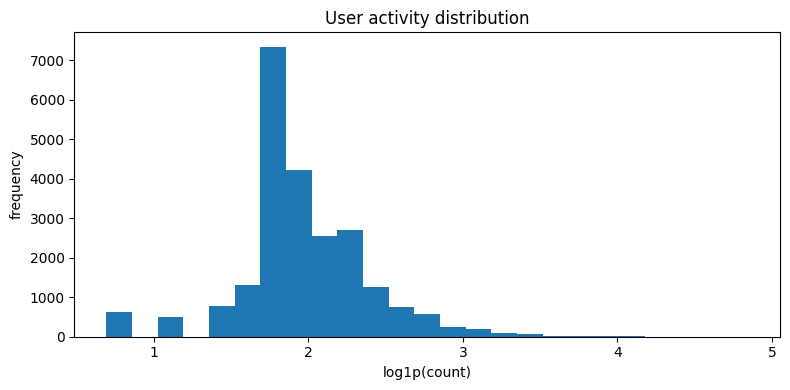

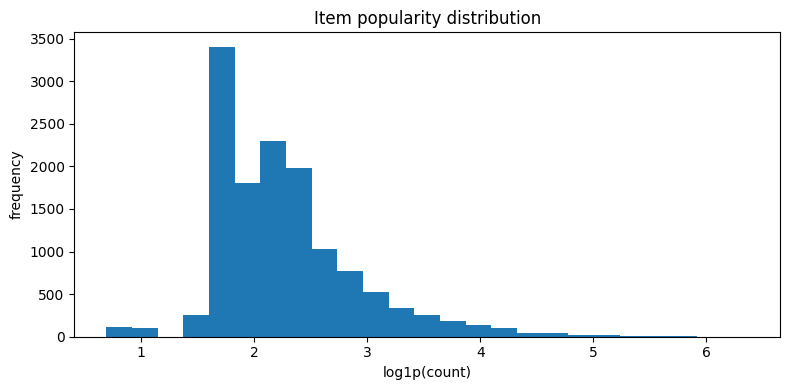

In [22]:
# User and item activity distributions.
user_counts = train_dedup.groupby('user_id').size().rename('n_interactions')
item_counts = train_dedup.groupby('item_id').size().rename('n_users')

print('User activity stats')
display(user_counts.describe(percentiles=[.01,.05,.25,.5,.75,.9,.95,.99]).to_frame().T)
print('Item popularity stats')
display(item_counts.describe(percentiles=[.01,.05,.25,.5,.75,.9,.95,.99]).to_frame().T)

for series, title, fname in [
    (user_counts, 'User activity distribution', 'user_activity_hist.png'),
    (item_counts, 'Item popularity distribution', 'item_popularity_hist.png'),
]:
    plt.figure(figsize=(8, 4))
    plt.hist(np.log1p(series.values), bins=25)
    plt.xlabel('log1p(count)')
    plt.ylabel('frequency')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / fname, dpi=150)
    plt.show()

In [11]:
# Sparsity.
n_users = train_dedup['user_id'].nunique()
n_items = train_dedup['item_id'].nunique()
n_observed = train_dedup.drop_duplicates(['user_id','item_id']).shape[0]
sparsity = 1 - n_observed / (n_users * n_items)
print(f'users={n_users:,}, items={n_items:,}, observed user-item pairs={n_observed:,}')
print(f'user-item matrix sparsity = {sparsity:.6%}')

users=23,284, items=13,441, observed user-item pairs=158,471
user-item matrix sparsity = 99.949364%


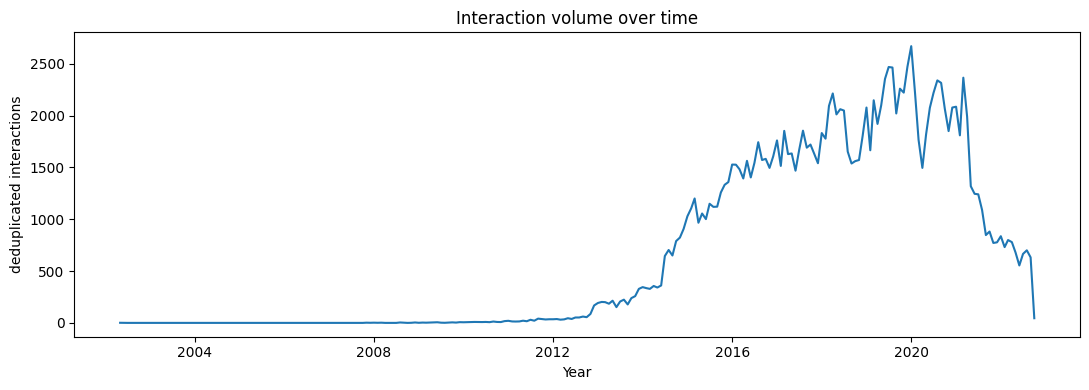

,datetime,interactions
234,2021-11-01 00:00:00+00:00,771
235,2021-12-01 00:00:00+00:00,777
236,2022-01-01 00:00:00+00:00,836
237,2022-02-01 00:00:00+00:00,731
238,2022-03-01 00:00:00+00:00,799
239,2022-04-01 00:00:00+00:00,779
240,2022-05-01 00:00:00+00:00,679
241,2022-06-01 00:00:00+00:00,554
242,2022-07-01 00:00:00+00:00,665
243,2022-08-01 00:00:00+00:00,700


In [23]:
# Temporal patterns.
monthly = train_dedup.set_index('datetime').resample('MS').size().rename('interactions').reset_index()
plt.figure(figsize=(11, 4))
plt.plot(monthly['datetime'], monthly['interactions'])
plt.xlabel('Year')
plt.ylabel('deduplicated interactions')
plt.title('Interaction volume over time')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'monthly_interactions.png', dpi=150)
plt.show()

display(monthly.tail(12))

In [13]:
# Train/validation/test distribution comparison by users/items.
def set_stats(a, b, a_name, b_name):
    users_a, users_b = set(a['user_id']), set(b['user_id'])
    items_a, items_b = set(a['item_id']), set(b['item_id'])
    return {
        f'{a_name}_users': len(users_a),
        f'{b_name}_users': len(users_b),
        'user_overlap': len(users_a & users_b),
        f'{b_name}_cold_users_vs_{a_name}': len(users_b - users_a),
        f'{a_name}_items': len(items_a),
        f'{b_name}_items': len(items_b),
        'item_overlap': len(items_a & items_b),
        f'{b_name}_cold_items_vs_{a_name}': len(items_b - items_a),
    }

display(pd.DataFrame([set_stats(local_train, local_valid, 'local_train', 'valid')]))

sample_users = set(sample['user_id'])
print('sample rows:', len(sample), 'sample users:', len(sample_users))
print('sample users in train:', len(sample_users & set(train_dedup.user_id)))
print('sample users in local validation:', len(sample_users & set(local_valid.user_id)))

,local_train_users,valid_users,user_overlap,valid_cold_users_vs_local_train,local_train_items,valid_items,item_overlap,valid_cold_items_vs_local_train
0,23284,7437,7437,0,13441,5984,5984,0


sample rows: 2255 sample users: 2255
sample users in train: 2255
sample users in local validation: 1285


In [14]:
# Submission format validation.
sub_lens = sample['item_id'].astype(str).str.split(',').map(len)
print('ID equals user_id:', bool((sample['ID'] == sample['user_id']).all()))
print('recommendation lengths in sample submission:')
print(sub_lens.value_counts().sort_index())
print('first sample row:')
display(sample.head())

ID equals user_id: True
recommendation lengths in sample submission:
item_id
10    2255
Name: count, dtype: int64
first sample row:


,ID,user_id,item_id
0,12,12,"6312,12419,6891,664,4243,8377,7962,6635,12842,..."
1,14,14,"7809,5867,9559,3579,8269,2282,4618,2290,12384,..."
2,17,17,"10132,13098,4105,8726,11554,13275,9862,2408,50..."
3,21,21,"11958,1209,11207,5410,7736,9172,1650,5797,7114..."
4,44,44,"10009,10493,3351,9053,7816,7254,8542,4268,1021..."


In [15]:
# Metadata coverage.
meta_item_ids = set(meta['item_id'])
train_item_ids = set(train_dedup['item_id'])
print('metadata rows/items:', len(meta), meta['item_id'].nunique())
print('train items with metadata:', len(train_item_ids & meta_item_ids), '/', len(train_item_ids))
print('train interactions with metadata:', train_dedup['item_id'].isin(meta_item_ids).mean())

meta_cov = pd.DataFrame({
    'item_id': item_counts.index,
    'popularity': item_counts.values,
})
meta_cov['has_meta'] = meta_cov['item_id'].isin(meta_item_ids)
for topn in [100, 500, 1000, 5000]:
    top = meta_cov.sort_values('popularity', ascending=False).head(topn)
    print(f'top {topn:5d} popularity items with metadata: {top.has_meta.mean():.3f}')

metadata rows/items: 7603 7603
train items with metadata: 7603 / 13441
train interactions with metadata: 0.5087870966927703
top   100 popularity items with metadata: 0.340
top   500 popularity items with metadata: 0.418
top  1000 popularity items with metadata: 0.457
top  5000 popularity items with metadata: 0.518


,main_category,store,average_rating,rating_number,price
0,Tools & Home Improvement,Scotch,4.8,514,63.49
1,Amazon Home,ChefLand,3.7,327,8.99
2,Industrial & Scientific,Robert Manufacturing,4.4,429,8.00
3,Industrial & Scientific,Velleman,3.6,54,NaN
4,Tools & Home Improvement,Klein Tools,4.6,935,NaN


main_category top values


,count
main_category,
Industrial & Scientific,4334
Tools & Home Improvement,1906
Amazon Home,311
Automotive,186
All Electronics,146
Health & Personal Care,132
Office Products,106
__MISSING__,94
Computers,62


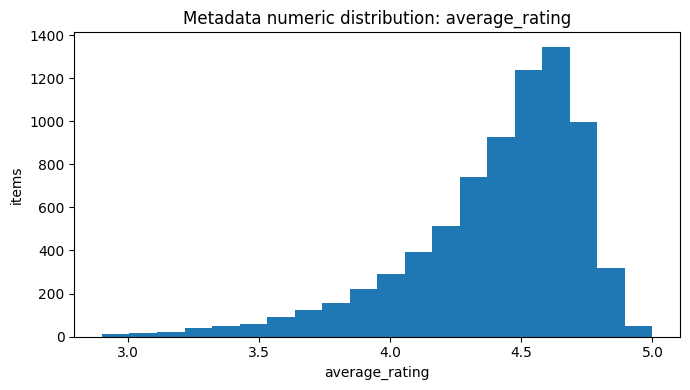

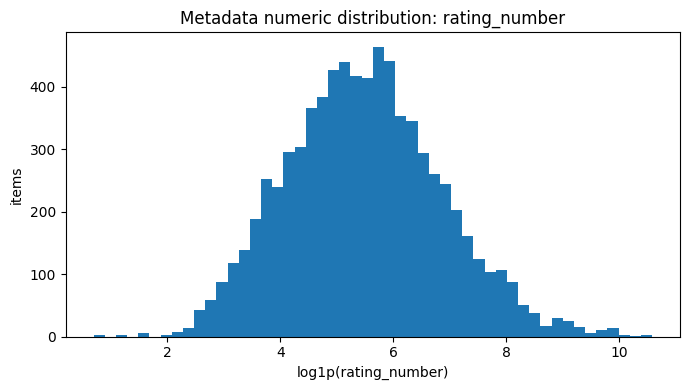

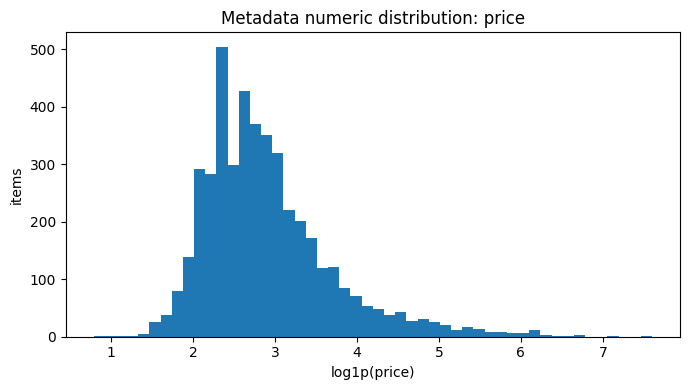

In [28]:
# Basic metadata feature diagnostics.
meta_diag_cols = ['main_category', 'store', 'average_rating', 'rating_number', 'price']
display(meta[meta_diag_cols].head())

print('main_category top values')
display(meta['main_category'].fillna('__MISSING__').value_counts().head(20).to_frame('count'))

for col in ['average_rating', 'rating_number', 'price']:
    plt.figure(figsize=(7, 4))
    vals = meta[col].dropna()
    if col in ['rating_number', 'price']:
        vals = np.log1p(vals)
        xlabel = f'log1p({col})'
    else:
        xlabel = col
    if col == 'average_rating':
        plt.hist(vals, bins=20)
    else:
        plt.hist(vals, bins=50)
    plt.xlabel(xlabel)
    plt.ylabel('items')
    plt.title(f'Metadata numeric distribution: {col}')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'meta_{col}_hist.png', dpi=150)
    plt.show()

In [ ]:
# text length diagnostics on metadata
text_cols = ['title', 'features', 'description', 'categories', 'details']
text_summary = []
for col in text_cols:
    s = meta[col].fillna('').astype(str)
    text_summary.append({
        'column': col,
        'missing_pct': meta[col].isna().mean() * 100,
        'mean_chars': s.str.len().mean(),
        'median_chars': s.str.len().median(),
        'empty_or_missing_pct': (s.str.len() == 0).mean() * 100,
    })
display(pd.DataFrame(text_summary))

,column,missing_pct,mean_chars,median_chars,empty_or_missing_pct
0,title,0.0,104.368276,96.0,0.0
1,features,0.0,451.977246,328.0,0.0
2,description,0.0,435.802709,212.0,0.0
3,categories,0.0,98.792845,102.0,0.0
4,details,0.0,411.147836,348.0,0.0
